# Hydrogenic Python demo

This notebook uses the installable `hydrogenic` Python package built from the C++ routines.

In [1]:
from pathlib import Path
import sys

for candidate in (Path.cwd() / "python/src", Path.cwd() / "src", Path.cwd().parent / "src"):
    if (candidate / "hydrogenic").exists():
        sys.path.insert(0, str(candidate))
        break

import numpy as np
import matplotlib.pyplot as plt

from hydrogenic import hydrogen, oxygen

plt.rcParams.update({
    "figure.figsize": (7.0, 4.8),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

## Construct atoms

In [2]:
h = hydrogen(shells=5)
o = oxygen(shells=30)

h.summary(), o.summary()

({'n_shells': 5,
  'nuclear_charge': 1,
  'nucleus_mass_in_mp': 1.0,
  'include_quadrupole_lines': True,
  'recombination_mode': 1,
  'level_count': 15},
 {'n_shells': 30,
  'nuclear_charge': 8,
  'nucleus_mass_in_mp': 15.879,
  'include_quadrupole_lines': True,
  'recombination_mode': 1,
  'level_count': 465})

## Level and transition data

In [3]:
h_2p = h.level(2, 1)
h_lya = h.transition(2, 1, 1, 0)
o_30_29 = o.level(30, 29)
o_high_n = o.transition(30, 29, 29, 28)

h_2p, h_lya, o_30_29, o_high_n

({'n': 2,
  'l': 1,
  'statistical_weight': 6.0,
  'ionization_energy_ev': 3.3995715179845813,
  'ionization_energy_erg': 5.446713552086828e-12,
  'ionization_frequency_hz': 822012807922942.2,
  'energy_difference_to_1s_ev': 10.198714553953744,
  'frequency_to_1s_hz': 2466038423768827.0,
  'a_total_per_s': 626490298.8026586,
  'a_e1_per_s': 626490298.8026586,
  'a_e2_per_s': 0.0,
  'gamma_per_s': 49854513.92678081,
  'lifetime_s': 1.5961939106019504e-09},
 {'upper_n': 2,
  'upper_l': 1,
  'lower_n': 1,
  'lower_l': 0,
  'a21_per_s': 626490298.8026586,
  'frequency_hz': 2466038423768827.0,
  'wavelength_cm': 1.2156844561319915e-05,
  'wavelength_angstrom': 1215.6844561319915},
 {'n': 30,
  'l': 29,
  'statistical_weight': 118.0,
  'ionization_energy_ev': 0.967482687912616,
  'ionization_energy_erg': 1.5500780141807675e-12,
  'ionization_frequency_hz': 233936293647784.38,
  'energy_difference_to_1s_ev': 869.7669364334419,
  'frequency_to_1s_hz': 2.1030872798935814e+17,
  'a_total_per_s':

## Ground-state photoionization cross sections

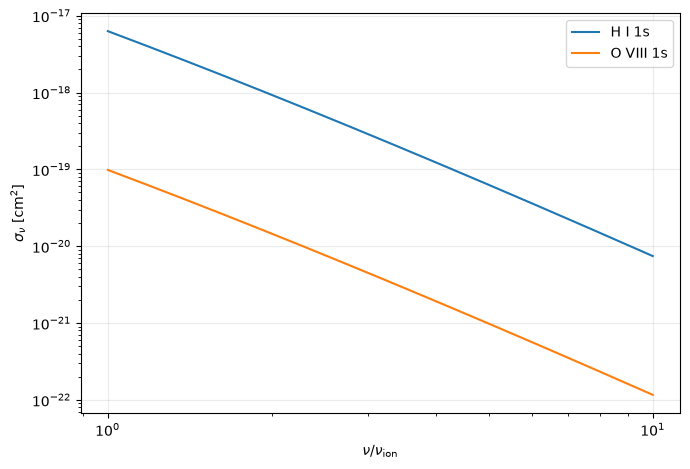

In [4]:
x = np.geomspace(1.001, 10.0, 300)

h_nu0 = h.level(1, 0)["ionization_frequency_hz"]
o_nu0 = o.level(1, 0)["ionization_frequency_hz"]

h_photo = h.photoionization(1, 0, x*h_nu0)
o_photo = o.photoionization(1, 0, x*o_nu0)

fig, ax = plt.subplots()
ax.loglog(x, h_photo["sigma_cm2"], label="H I 1s")
ax.loglog(x, o_photo["sigma_cm2"], label="O VIII 1s")
ax.set_xlabel(r"$\nu / \nu_{\mathrm{ion}}$")
ax.set_ylabel(r"$\sigma_{\nu}$ [cm$^2$]")
ax.legend()
fig.tight_layout()

## High-shell oxygen cross sections and Gaunt factors

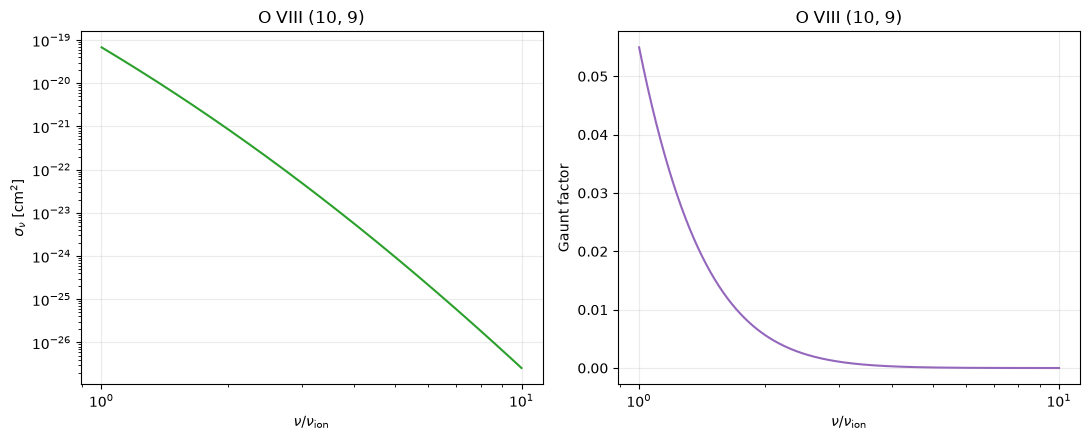

In [5]:
o_10_9_nu0 = o.level(10, 9)["ionization_frequency_hz"]
o_10_9_photo = o.photoionization(10, 9, x*o_10_9_nu0)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.5))

axes[0].loglog(x, o_10_9_photo["sigma_cm2"], color="tab:green")
axes[0].set_xlabel(r"$\nu / \nu_{\mathrm{ion}}$")
axes[0].set_ylabel(r"$\sigma_{\nu}$ [cm$^2$]")
axes[0].set_title("O VIII (10, 9)")

axes[1].semilogx(x, o_10_9_photo["gaunt"], color="tab:purple")
axes[1].set_xlabel(r"$\nu / \nu_{\mathrm{ion}}$")
axes[1].set_ylabel("Gaunt factor")
axes[1].set_title("O VIII (10, 9)")

fig.tight_layout()